### SVR (Support Vector Regression) sur Diabetes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_diabetes
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler
import time

In [3]:
# CHARGEMENT & PREPROCESSING

print("Chargement du dataset Diabetes...")
data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"    Shape X : {X.shape}  |  Shape y : {y.shape}")
print(f"    Target  — min : {y.min():.1f}  max : {y.max():.1f}  mean : {y.mean():.1f}")
print(f"    Features : {feature_names}")

# StandardScaler — indispensable pour SVR (sensible aux échelles)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print(f"\n    StandardScaler appliqué sur X et y")

# Split 80/20
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)
# Garder y original pour les métriques interprétables
_, _, y_tr_raw, y_te_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"    Train : {X_tr.shape[0]} | Test : {X_te.shape[0]}")

Chargement du dataset Diabetes...
    Shape X : (442, 10)  |  Shape y : (442,)
    Target  — min : 25.0  max : 346.0  mean : 152.1
    Features : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

    StandardScaler appliqué sur X et y
    Train : 353 | Test : 89


In [5]:
configs = [
    {"kernel": "linear", "C": 1.0,  "epsilon": 0.1},
    {"kernel": "rbf",    "C": 1.0,  "epsilon": 0.1},
    {"kernel": "rbf",    "C": 10.0, "epsilon": 0.1},
    {"kernel": "poly",   "C": 1.0,  "epsilon": 0.1, "degree": 3},
]

results = []  # ← initialisation avant la boucle

for cfg in configs:
    label = f"{cfg['kernel'].upper()} C={cfg['C']}"
    svr   = SVR(**{k: v for k, v in cfg.items()})
    svr.fit(X_tr, y_tr)

    y_pred_scaled = svr.predict(X_te)
    y_pred_raw    = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    r2   = r2_score(y_te_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_te_raw, y_pred_raw))
    mae  = mean_absolute_error(y_te_raw, y_pred_raw)

    results.append({
        "svr": svr, "label": label, "r2": r2,
        "rmse": rmse, "mae": mae, "y_pred_raw": y_pred_raw, **cfg
    })
    print(f"    {label:<20} → R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}")

best = max(results, key=lambda r: r["r2"])
print(f"\n    Meilleur modèle : {best['label']} → R²={best['r2']:.4f}")

    LINEAR C=1.0         → R²=0.4439  RMSE=54.28  MAE=43.10
    RBF C=1.0            → R²=0.5242  RMSE=50.21  MAE=38.88
    RBF C=10.0           → R²=0.2739  RMSE=62.03  MAE=46.28
    POLY C=1.0           → R²=0.3186  RMSE=60.09  MAE=49.19

    Meilleur modèle : RBF C=1.0 → R²=0.5242


In [6]:
# ÉVALUATION

y_pred_best = best["y_pred_raw"]

print(f"    Meilleur modèle : {best['label']}")
print(f"    R²   : {best['r2']:.4f}")
print(f"    RMSE : {best['rmse']:.2f}")
print(f"    MAE  : {best['mae']:.2f}")

# Cross-validation 5-fold sur le meilleur modèle
svr_cv = SVR(**{k: v for k, v in best.items() if k in ["kernel", "C", "epsilon", "degree"]})
cv_scores = cross_val_score(svr_cv, X_scaled, y_scaled, cv=5, scoring="r2")
print(f"\n    Cross-validation R² (5-fold) :")
for i, s in enumerate(cv_scores):
    bar = "█" * int(max(s, 0) * 20)
    print(f"      Fold {i+1} : {bar:<20} {s:.4f}")
print(f"      Moyenne : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Résidus
residuals = y_te_raw - y_pred_best
print(f"\n    Résidus — mean : {residuals.mean():.2f}  std : {residuals.std():.2f}")
print(f"    % prédictions dans ±30 : {np.mean(np.abs(residuals) < 30)*100:.1f}%")
print(f"    % prédictions dans ±50 : {np.mean(np.abs(residuals) < 50)*100:.1f}%")

    Meilleur modèle : RBF C=1.0
    R²   : 0.5242
    RMSE : 50.21
    MAE  : 38.88

    Cross-validation R² (5-fold) :
      Fold 1 : ██████               0.3402
      Fold 2 : ███████████          0.5715
      Fold 3 : ████████             0.4445
      Fold 4 : ███████              0.3891
      Fold 5 : ██████████           0.5200
      Moyenne : 0.4531 ± 0.0841

    Résidus — mean : 4.59  std : 50.00
    % prédictions dans ±30 : 50.6%
    % prédictions dans ±50 : 70.8%


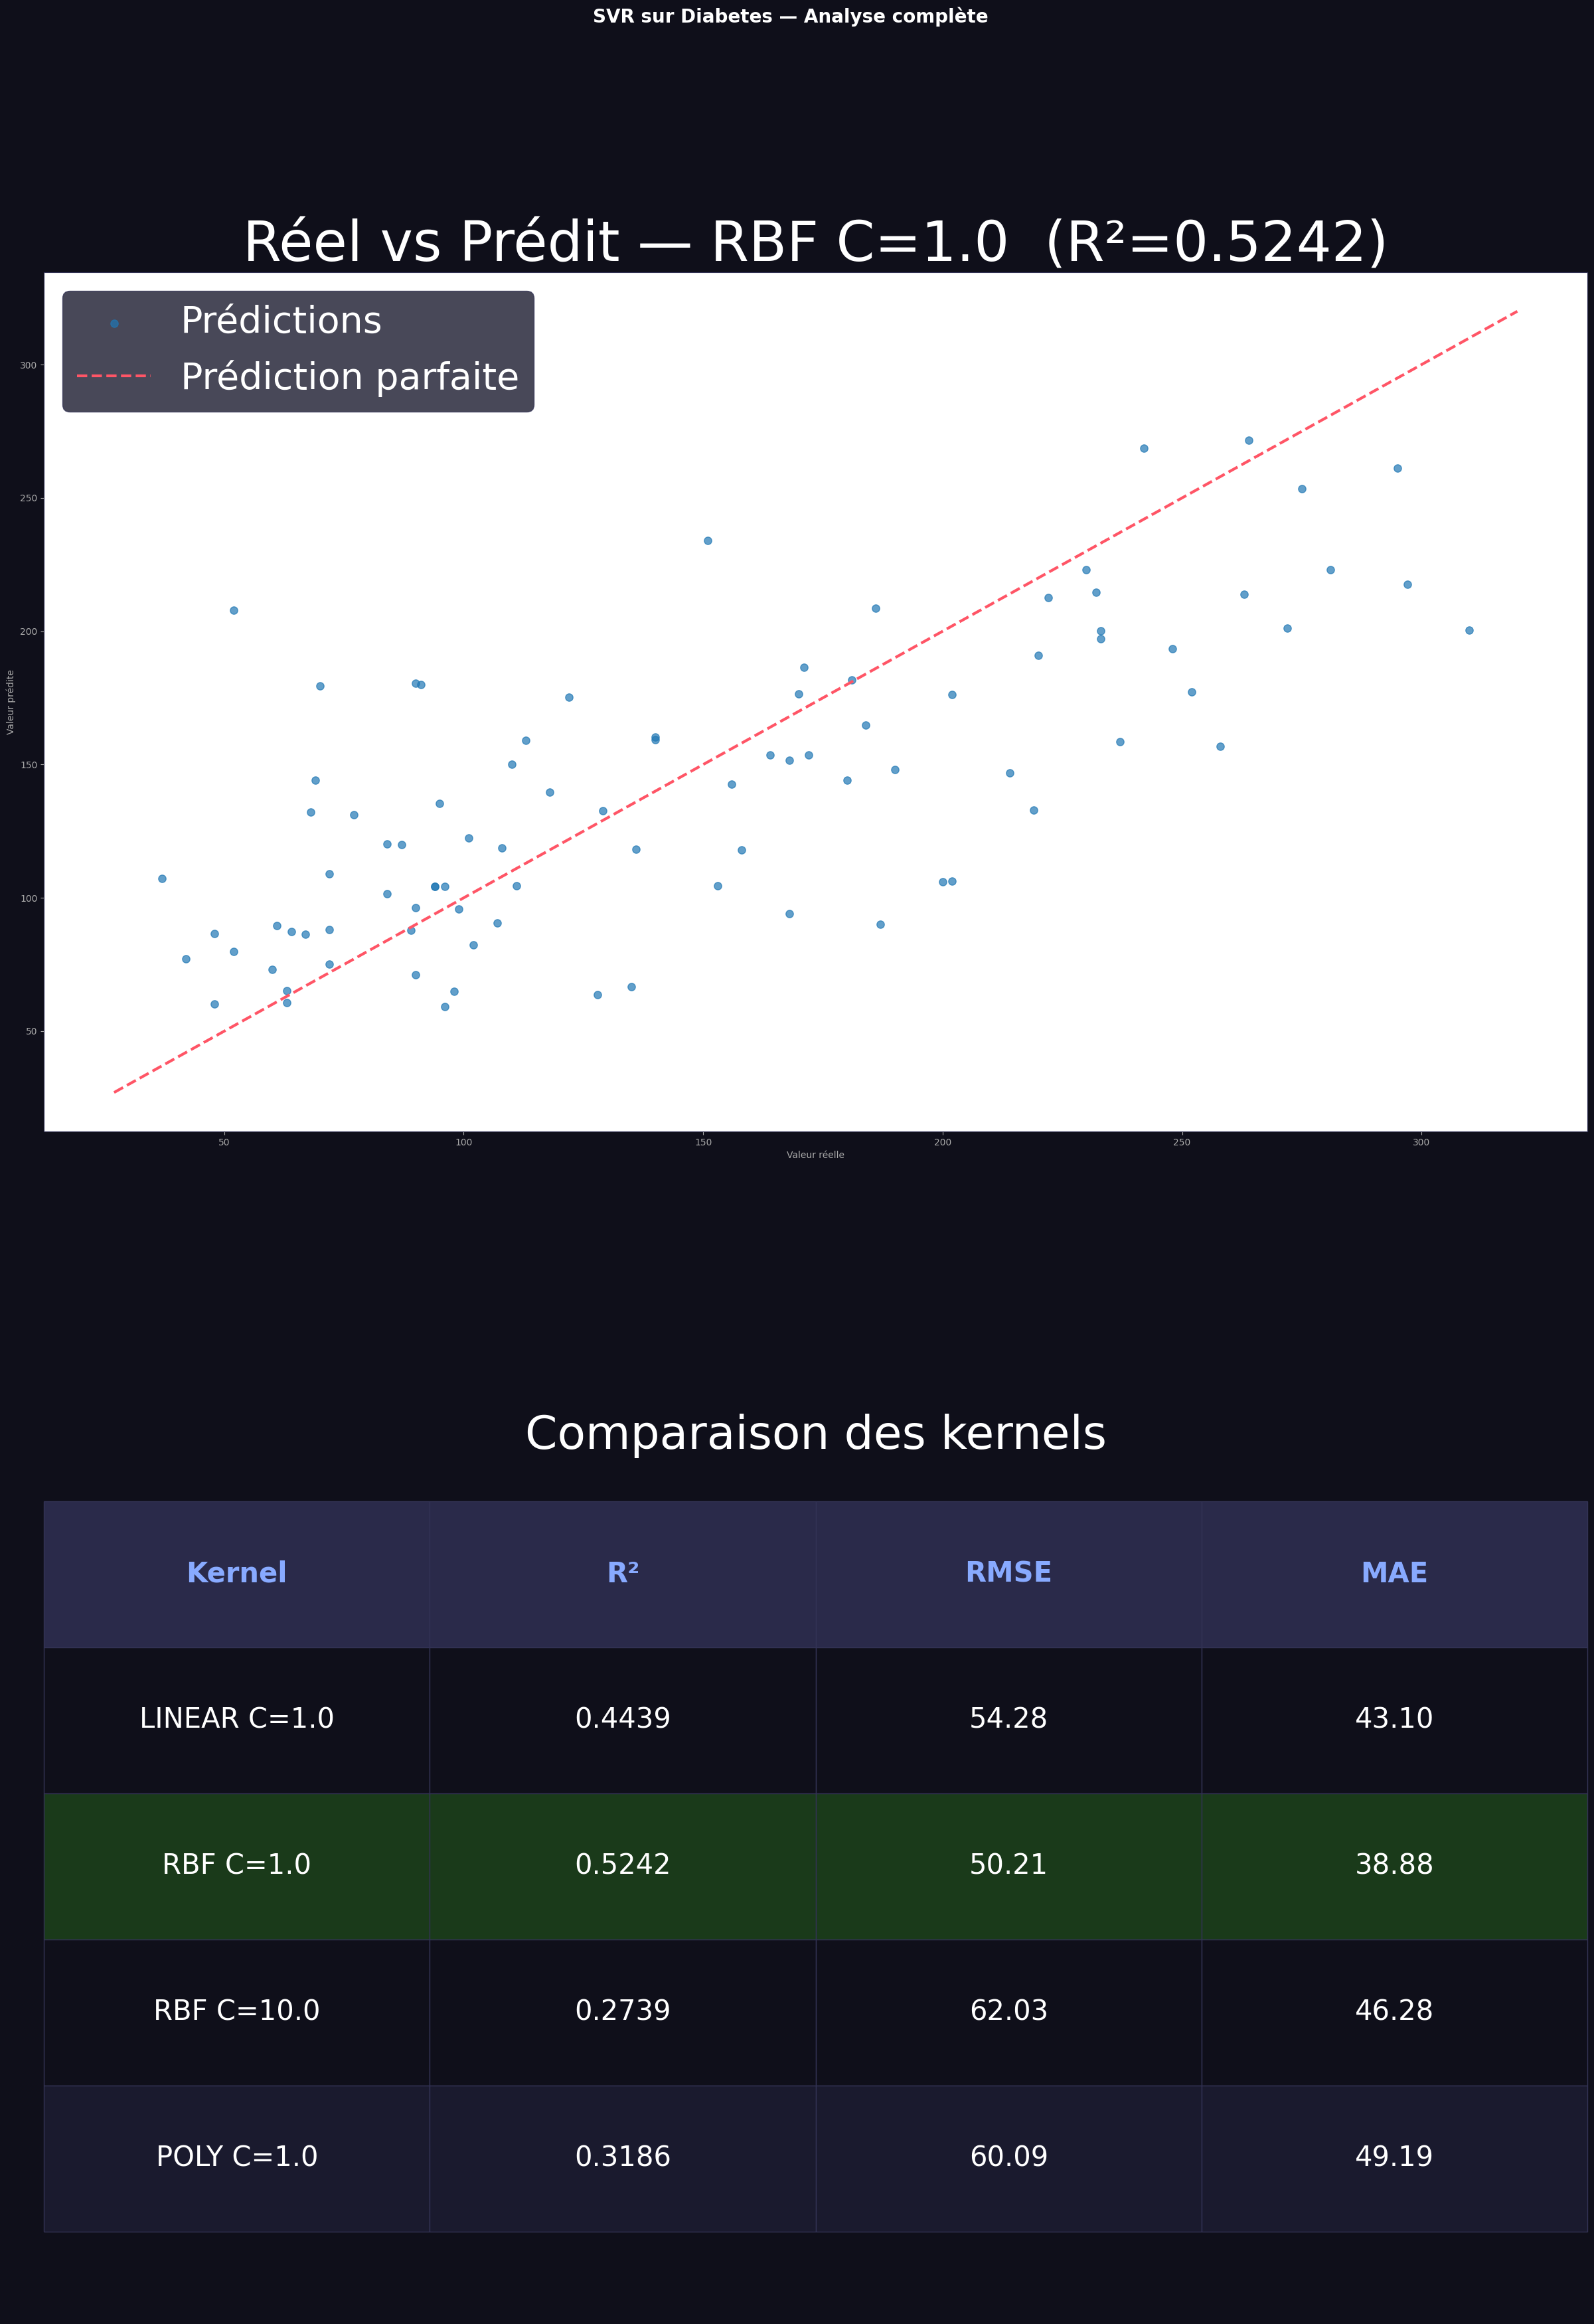

In [7]:
# VISUALISATION

COLORS = plt.cm.tab10(np.linspace(0, 1, 10))
plt.style.use("default")

fig = plt.figure(figsize=(30, 40), facecolor="#0f0f1a")
fig.suptitle("SVR sur Diabetes — Analyse complète",
             fontsize=20, fontweight="bold", color="white", y=0.98)

gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.38, wspace=0.3)

def style_ax(ax):
    ax.tick_params(colors="#aaaaaa")
    for spine in ax.spines.values():
        spine.set_color("#333355")

#  Réel vs Prédit (meilleur modèle) ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_te_raw, y_pred_best, color=COLORS[0], s=66, alpha=0.7, label="Prédictions")
lims = [min(y_te_raw.min(), y_pred_best.min()) - 10,
        max(y_te_raw.max(), y_pred_best.max()) + 10]
ax1.plot(lims, lims, color="#ff5566", linewidth=3, linestyle="--", label="Prédiction parfaite")
ax1.set_title(f"Réel vs Prédit — {best['label']}  (R²={best['r2']:.4f})", fontsize=60, color="white")
ax1.set_xlabel("Valeur réelle", color="#aaaaaa")
ax1.set_ylabel("Valeur prédite", color="#aaaaaa")
style_ax(ax1)
leg = ax1.legend(fontsize=40, labelcolor="white", facecolor="#1a1a2e", edgecolor="#333355")


# Tableau récapitulatif ──
ax_tab = fig.add_subplot(gs[1, 0])
ax_tab.axis("off")
metrics_data = [
    ["Kernel", "R²", "RMSE", "MAE"],
    *[[r["label"], f"{r['r2']:.4f}", f"{r['rmse']:.2f}", f"{r['mae']:.2f}"] for r in results],
]
table = ax_tab.table(
    cellText=metrics_data[1:],
    colLabels=metrics_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0.1, 1, 0.85]
)
table.auto_set_font_size(False)
table.set_fontsize(30)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor("#1a1a2e" if r % 2 == 0 else "#0f0f1a")
    cell.set_edgecolor("#333355")
    cell.set_text_props(color="white")
    if r == 0:
        cell.set_facecolor("#2a2a4a")
        cell.set_text_props(weight="bold", color="#88aaff")
    if r > 0 and metrics_data[r][0] == best["label"]:
        cell.set_facecolor("#1a3a1a")
ax_tab.set_title("Comparaison des kernels", fontsize=50, color="white", pad=10)
plt.show()
